# Impact sur les revenus au Box-Office

Le but est de répondre précisément à la question centrale de ta problématique : Est-ce que les livres populaires font les meilleurs scores au Box-Office ?

## Importations, Configuration et Filtrage

In [4]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration esthétique
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Connexion à la base de données
DB_PATH = os.path.join("..", "database", "cinema.db")
if not os.path.exists(DB_PATH):
    raise FileNotFoundError(f"❌ Base de données introuvable à l'emplacement : {DB_PATH}")
    
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM adaptations", conn)
conn.close()

# Nettoyage ciblé : on ne garde que les films avec des recettes renseignées
df_finance = df.dropna(subset=['revenue (millions)']).copy()

print(f"✅ Données financières chargées.")
print(f"📊 {df_finance.shape[0]} adaptations disposent de données exploitables au Box-Office.")

✅ Données financières chargées.
📊 69 adaptations disposent de données exploitables au Box-Office.


## Calcul des corrélations économiques

On va calculer les coefficients de Pearson pour mesurer deux relations cruciales :

- L'impact du livre sur les recettes.

- L'impact de la qualité finale du film sur les recettes.

In [5]:
# Calcul des corrélations de Pearson
corr_livre_recettes = df_finance['rating_average'].corr(df_finance['revenue (millions)'])
corr_film_recettes = df_finance['rating'].corr(df_finance['revenue (millions)'])

print("--- ANALYSE STATISTIQUE DES RECETTES ---")
print(f"Corrélation [Note du Livre ➔ Recettes du Film] : {corr_livre_recettes:.2f}")
print(f"Corrélation [Note du Film  ➔ Recettes du Film] : {corr_film_recettes:.2f}")
print(f"Recettes moyennes de l'échantillon : {df_finance['revenue (millions)'].mean():.2f} M$")
print(f"Recettes maximales enregistrées     : {df_finance['revenue (millions)'].max():.2f} M$")

--- ANALYSE STATISTIQUE DES RECETTES ---
Corrélation [Note du Livre ➔ Recettes du Film] : 0.30
Corrélation [Note du Film  ➔ Recettes du Film] : 0.22
Recettes moyennes de l'échantillon : 96.38 M$
Recettes maximales enregistrées     : 408.00 M$


Ces indicateurs statistiques nous permettent d'apporter une réponse directe et nuancée à : les livres populaires font-ils les meilleurs scores au Box-Office ?

- Un lien très faible entre popularité littéraire et recettes ($r = 0,30$) : L'indice de Pearson révèle une corrélation positive mais faible entre la note du livre d'origine et le revenus généré en salles. Cela signifie que le plébiscite d'un livre par sa communauté de lecteurs n'est absolument pas un gage de grand gain financier à Hollywood. Un chef-d'œuvre de la littérature peut très bien faire un flop commercial, tandis qu'un livre jugé "moyen" peut se transformer en immense succès populaire au cinéma.

- Le décalage de perception critique ($r = 0,22$) : Plus surprenant, la corrélation entre la note finale du film (IMDb) et ses propres recettes est encore plus basse ($0,22$). En clair, la qualité intrinsèque du film n'influence presque pas son succès au Box-Office. Un film descendu par la critique peut tout à fait attirer quand même le public dans les salles et ainsi générer beaucoup de revenus.

- Le poids des géants économiques : Avec des recettes moyennes s'élevant à 96,38 millions de dollars et un sommet important enregistré à 408 millions, notre échantillon montre une forte asymétrie. Ce grand écart financier s'explique par des facteurs totalement déconnectés de la qualité d'écriture ou de réalisation. Ce sont principalement les budgets de production, les campagnes marketing massives, la distribution des rôles (casting d'acteurs de premier plan) et les choix de réalisation qui dictent plutôt le succès financier.
 
En résumé : L'industrie cinématographique obéit à ses propres logiques commerciales : la popularité d'un livre sert de tremplin de notoriété ou de base de fans initiale, mais c'est la puissance de la machine hollywoodienne qui détermine les scores au Box-Office.

## Popularité littéraire vs Box office

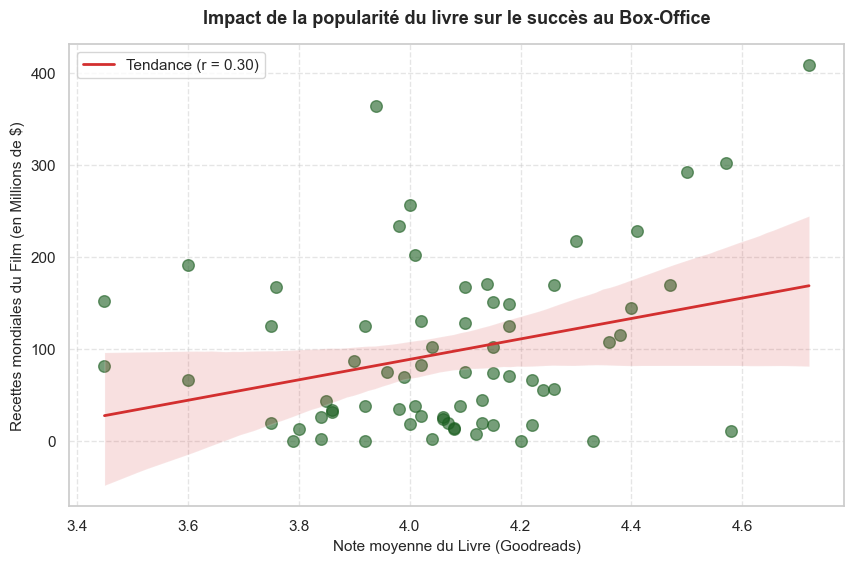

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_finance, 
    x='rating_average', 
    y='revenue (millions)', 
    color='#1b5e20',
    scatter_kws={'alpha': 0.6, 's': 70},
    line_kws={'color': '#d32f2f', 'lw': 2, 'label': f'Tendance (r = {corr_livre_recettes:.2f})'}
)

plt.title("Impact de la popularité du livre sur le succès au Box-Office", fontsize=13, pad=15, fontweight='bold')
plt.xlabel("Note moyenne du Livre (Goodreads)", fontsize=11)
plt.ylabel("Recettes mondiales du Film (en Millions de $)", fontsize=11)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

# Sauvegarde
os.makedirs("../reports/figures", exist_ok=True)
plt.savefig("../reports/figures/2_popularite_livre_vs_recettes.png", bbox_inches='tight', dpi=150)
plt.show()

La pente ascendante confirme qu’un bon livre offre une base de départ positive, mais le score de $0,30$ prouve que la note littéraire ne dicte pas les revenus en salles.

Entre $3,9$ et $4,2$ (la majorité des livres), les recettes explosent ou s'effondrent de manière totalement aléatoire, variant de 0 à près de 400 millions de dollars.

Le graphique montre des livres moyens devenus des blockbusters à plus de 350 M$ (haut gauche), et des chefs-d'œuvre littéraires à $4,6$ qui font un flop sous les 50 M$ (bas droite)

**En résumé :** La popularité d'un livre n'est qu'un léger tremplin. Le Box-Office obéit avant tout aux règles d'Hollywood (budgets, casting, marketing).

## Recettes x Note film x Note livre

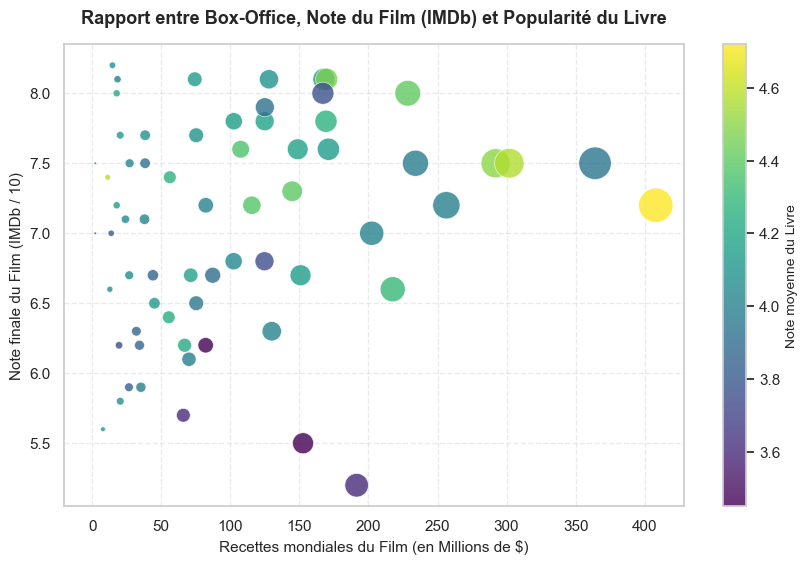

In [7]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    data=df_finance, 
    x='revenue (millions)', 
    y='rating', 
    c='rating_average', # Couleur selon la note du livre
    cmap='viridis',
    s=df_finance['revenue (millions)'] * 1.5, # Taille du point proportionnelle aux recettes
    alpha=0.8,
    edgecolors='w',
    linewidth=0.5
)

plt.title("Rapport entre Box-Office, Note du Film (IMDb) et Popularité du Livre", fontsize=13, pad=15, fontweight='bold')
plt.xlabel("Recettes mondiales du Film (en Millions de $)", fontsize=11)
plt.ylabel("Note finale du Film (IMDb / 10)", fontsize=11)

# Ajout de la barre de couleur pour la note du livre
cbar = plt.colorbar(scatter)
cbar.set_label("Note moyenne du Livre", fontsize=10)

plt.grid(True, linestyle='--', alpha=0.4)

plt.savefig("../reports/figures/2_box_office_vs_qualite_film.png", bbox_inches='tight', dpi=150)
plt.show()

Ce graphique croise les recettes (axe $X$), la note du film (axe $Y$), la taille des bulles (volume du succès financier) et leur couleur (note du livre d'origine).

- La zone des gros succès commerciaux ($> 200\text{ M\$}$) se concentre exclusivement dans le haut du graphique (notes IMDb entre $6,5$ et $8,0$). Hollywood ne génère pas de méga-blockbusters avec des films purement catastrophiques : un niveau de qualité minimum ou de divertissement validé par le public est requis pour atteindre ces sommets.
- Tout à droite, le plus gros succès financier du dataset ($\approx 408\text{ M\$}$) affiche une note de film correcte ($7,2/10$) mais possède une couleur jaune vif ($> 4,6/5$ pour le livre). C'est l'illustration parfaite d'un livre ultra-populaire, transformé en blockbuster très grand public et rentable.
- Plus on va vers la gauche (faibles recettes), plus la dispersion verticale est totale (les notes des films s'étalent de $5,0$ à $8,2$). Cela prouve qu'un excellent film critique (noté $> 8,0$ tout en haut à gauche) peut rester un projet de niche ou d'auteur avec de très faibles revenus, tandis que les "mauvais" films (notés $< 6,0$) restent condamnés à de petits budgets ou des flops financiers.
- Les points violets (livres moins bien notés) sont presque tous au fond du graphique (faibles notes de films et faibles recettes). À l'inverse, les teintes vertes et jaunes (bons livres) squattent le haut et la droite, confirmant que la qualité du livre d'origine reste le meilleur bouclier contre un naufrage critique global.
 
En résumé : Si un bon livre ne garantit pas la richesse ($r=0,30$), un mauvais film garantit presque à coup sûr la pauvreté au Box-Office. Le succès commercial massif exige l'alignement d'une note cinématographique solide et, idéalement, d'un livre d'origine fortement plébiscité.

## Top 5 des adaptations générant le plus de revenu

In [9]:
print("--- TOP 5 DES ADAPTATIONS LES PLUS RENTABLES ---")
top_5 = df_finance.sort_values(by='revenue (millions)', ascending=False).head(5)

for i, (_, row) in enumerate(top_5.iterrows(), 1):
    print(f"{i}. 🎬 {row['title'].upper()} ({int(row['year'])})")
    print(f"   💰 Recettes : {row['revenue (millions)']} M$")
    print(f"   📚 Note du Livre : {row['rating_average']}/5 | Note du Film : {row['rating']}/10\n")

--- TOP 5 DES ADAPTATIONS LES PLUS RENTABLES ---
1. 🎬 THE HUNGER GAMES (2012)
   💰 Recettes : 408.0 M$
   📚 Note du Livre : 4.72/5 | Note du Film : 7.2/10

2. 🎬 THE JUNGLE BOOK (2016)
   💰 Recettes : 364.0 M$
   📚 Note du Livre : 3.94/5 | Note du Film : 7.5/10

3. 🎬 HARRY POTTER AND THE HALF-BLOOD PRINCE (2009)
   💰 Recettes : 301.96 M$
   📚 Note du Livre : 4.57/5 | Note du Film : 7.5/10

4. 🎬 HARRY POTTER AND THE ORDER OF THE PHOENIX (2007)
   💰 Recettes : 292.0 M$
   📚 Note du Livre : 4.5/5 | Note du Film : 7.5/10

5. 🎬 I AM LEGEND (2007)
   💰 Recettes : 256.39 M$
   📚 Note du Livre : 4.0/5 | Note du Film : 7.2/10

